In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import grangercausalitytests
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

ROOT      = Path('..').resolve()
GOLD_PATH = ROOT / 'data' / 'gold' / 'model_dataset_monthly.csv'
FIG_DIR   = ROOT / 'outputs' / 'figures'
REP_DIR   = ROOT / 'outputs' / 'reports'

df = pd.read_csv(GOLD_PATH, parse_dates=['month'], index_col='month')
df.index.freq = 'MS'
print(f'Gold dataset : {df.shape}  |  {df.index.min().date()} -> {df.index.max().date()}')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10, 'axes.grid': True, 'grid.alpha': 0.3})
sns.set_palette('Set2')

Gold dataset : (96, 29)  |  2017-01-01 -> 2024-12-01


In [2]:
# ── Test de Chow : rupture structurelle 2022-03 ──────────────────────────────
# La rupture de mars 2022 = debut du choc inflationniste (guerre Ukraine)
# On compare les parametres SARIMA avant/apres sur inflation_yoy

if 'inflation_yoy' not in df.columns:
    print('inflation_yoy absent — rupture non testable')
else:
    BREAK_DATE = pd.Timestamp('2022-03-01')
    series = df['inflation_yoy'].dropna()
    pre    = series[series.index < BREAK_DATE]
    post   = series[series.index >= BREAK_DATE]

    print('=== TEST DE RUPTURE STRUCTURELLE ===')
    print(f'Point de rupture : {BREAK_DATE.date()}')
    print(f'Pre-rupture  : {len(pre)} obs  | mean={pre.mean():.2f}%  std={pre.std():.2f}%')
    print(f'Post-rupture : {len(post)} obs  | mean={post.mean():.2f}%  std={post.std():.2f}%')

    # Test de Chow simplifie : F-test de la difference de moyennes
    t_stat, p_val = stats.ttest_ind(pre, post, equal_var=False)
    print(f'\nTest t (difference de moyennes) :')
    print(f'  t={t_stat:.3f}  p={p_val:.4f}  => {"RUPTURE SIGNIFICATIVE" if p_val < 0.05 else "non sig."}')

    # Test de Levene (variance)
    lev_stat, lev_p = stats.levene(pre, post)
    print(f'\nTest de Levene (difference de variance) :')
    print(f'  W={lev_stat:.3f}  p={lev_p:.4f}  => {"Variance differente" if lev_p < 0.05 else "Variance similaire"}')

    print(f'\nInterpretation :')
    print(f'  Avant 2022 : inflation moyenne = {pre.mean():.2f}%')
    print(f'  Apres 2022 : inflation moyenne = {post.mean():.2f}%')
    print(f'  Hausse = +{post.mean()-pre.mean():.2f} points (x{post.mean()/max(pre.mean(),0.01):.1f})')

=== TEST DE RUPTURE STRUCTURELLE ===
Point de rupture : 2022-03-01
Pre-rupture  : 50 obs  | mean=0.74%  std=2.22%
Post-rupture : 34 obs  | mean=8.53%  std=6.64%

Test t (difference de moyennes) :
  t=-6.600  p=0.0000  => RUPTURE SIGNIFICATIVE

Test de Levene (difference de variance) :
  W=48.528  p=0.0000  => Variance differente

Interpretation :
  Avant 2022 : inflation moyenne = 0.74%
  Apres 2022 : inflation moyenne = 8.53%
  Hausse = +7.80 points (x11.6)


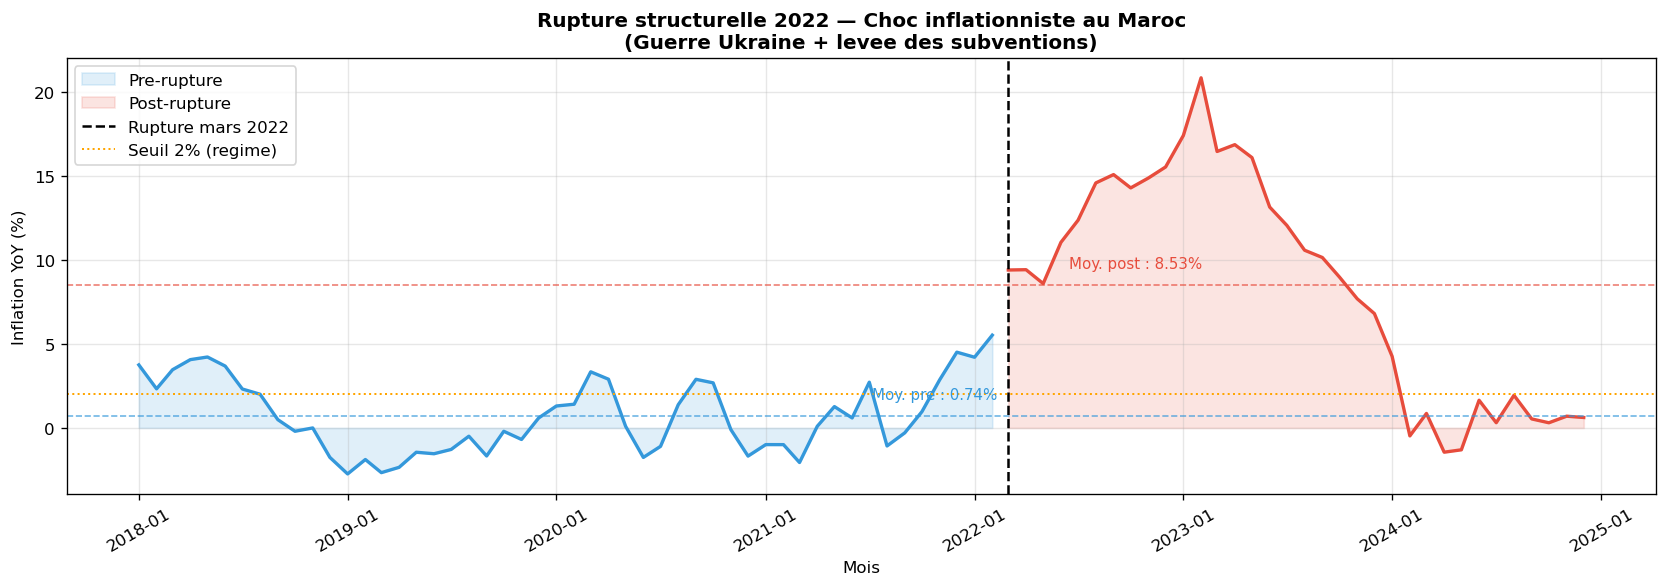

Figure sauvegardee : structural_break_v3.png


In [3]:
# ── Visualisation de la rupture structurelle ─────────────────────────────────
if 'inflation_yoy' in df.columns:
    BREAK_DATE = pd.Timestamp('2022-03-01')
    fig, ax = plt.subplots(figsize=(14, 5))

    series = df['inflation_yoy'].dropna()
    pre  = series[series.index < BREAK_DATE]
    post = series[series.index >= BREAK_DATE]

    ax.fill_between(pre.index,  0, pre.values,  alpha=0.15, color='#3498db', label='Pre-rupture')
    ax.fill_between(post.index, 0, post.values, alpha=0.15, color='#e74c3c', label='Post-rupture')
    ax.plot(pre.index,  pre.values,  color='#3498db', linewidth=2)
    ax.plot(post.index, post.values, color='#e74c3c', linewidth=2)

    ax.axvline(BREAK_DATE, color='black', linestyle='--', linewidth=1.5, label='Rupture mars 2022')
    ax.axhline(2.0, color='orange', linestyle=':', linewidth=1.2, label='Seuil 2% (regime)')
    ax.axhline(pre.mean(),  color='#3498db', linestyle='--', linewidth=1, alpha=0.7)
    ax.axhline(post.mean(), color='#e74c3c', linestyle='--', linewidth=1, alpha=0.7)

    ax.annotate(f'Moy. pre : {pre.mean():.2f}%', xy=(pre.index[-5], pre.mean()),
                xytext=(-30, 10), textcoords='offset points', color='#3498db', fontsize=9)
    ax.annotate(f'Moy. post : {post.mean():.2f}%', xy=(post.index[3], post.mean()),
                xytext=(5, 10), textcoords='offset points', color='#e74c3c', fontsize=9)

    ax.set_xlabel('Mois')
    ax.set_ylabel('Inflation YoY (%)')
    ax.set_title('Rupture structurelle 2022 — Choc inflationniste au Maroc\n'
                 '(Guerre Ukraine + levee des subventions)', fontweight='bold')
    ax.legend(loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'structural_break_v3.png', bbox_inches='tight')
    plt.show()
    print('Figure sauvegardee : structural_break_v3.png')

In [4]:
# ── Test de causalite de Granger : BESI -> inflation_yoy ──────────────────────
if 'behavioral_index_pure' in df.columns and 'inflation_yoy' in df.columns:
    granger_df = df[['inflation_yoy', 'behavioral_index_pure']].dropna()
    print(f'Granger test : {len(granger_df)} observations')
    print(f'H0 : behavioral_index_pure ne cause pas au sens de Granger inflation_yoy\n')

    results = grangercausalitytests(granger_df, maxlag=4, verbose=False)

    print(f'{"Lag":<6} {"F-stat":<10} {"p-value":<10} {"Conclusion"}')
    print('-' * 45)
    for lag, res in results.items():
        f_stat = res[0]['ssr_ftest'][0]
        p_val  = res[0]['ssr_ftest'][1]
        sig = '** Significatif **' if p_val < 0.05 else f'(p={p_val:.3f})'
        print(f'{lag:<6} {f_stat:<10.3f} {p_val:<10.4f} {sig}')

    # Sauvegarder les resultats
    granger_rows = []
    for lag, res in results.items():
        granger_rows.append({
            'lag': lag,
            'f_stat': res[0]['ssr_ftest'][0],
            'p_value': res[0]['ssr_ftest'][1],
            'significant': res[0]['ssr_ftest'][1] < 0.05,
            'signal': 'behavioral_index_pure',
            'target': 'inflation_yoy'
        })
    granger_res = pd.DataFrame(granger_rows)
    granger_res.to_csv(REP_DIR / 'granger_besi_v3.csv', index=False)
    print(f'\nResultats sauvegardes : granger_besi_v3.csv')

Granger test : 84 observations
H0 : behavioral_index_pure ne cause pas au sens de Granger inflation_yoy

Lag    F-stat     p-value    Conclusion
---------------------------------------------
1      0.238      0.6273     (p=0.627)
2      0.248      0.7813     (p=0.781)
3      0.235      0.8715     (p=0.872)
4      0.200      0.9376     (p=0.938)

Resultats sauvegardes : granger_besi_v3.csv


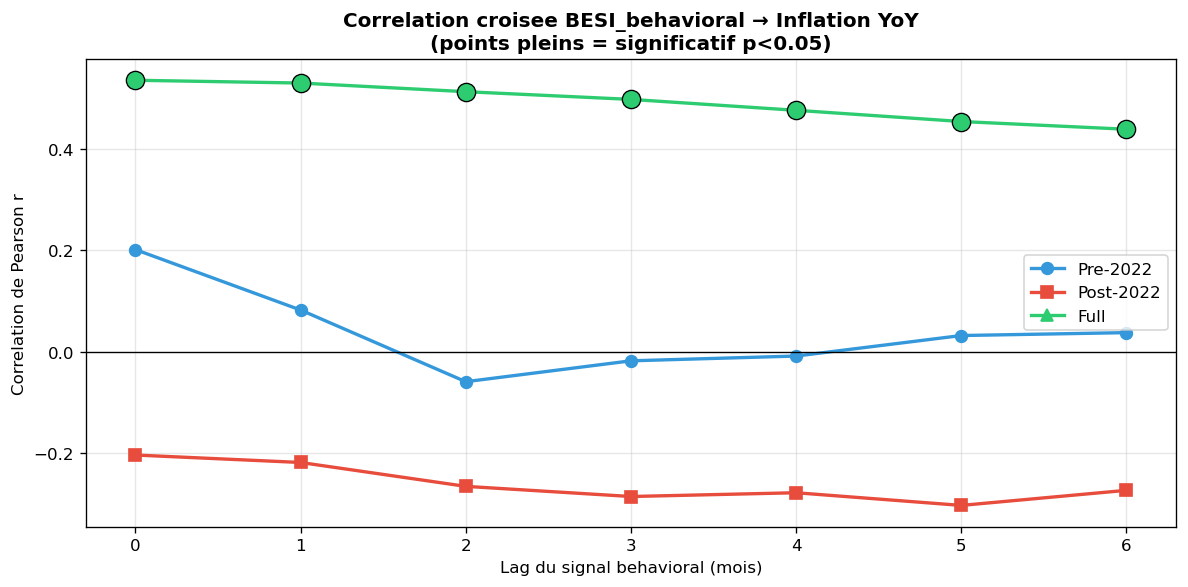

Correlation maximale par periode :
  Pre-2022     lag=0  r=+0.201  p=0.161
  Post-2022    lag=5  r=-0.303  p=0.110
  Full         lag=0  r=+0.535  p=0.000


In [5]:
# ── Analyse des correlations croisees par sous-periode ──────────────────────
if 'behavioral_index_pure' in df.columns and 'inflation_yoy' in df.columns:
    BREAK_DATE = pd.Timestamp('2022-03-01')
    lags_range = range(0, 7)

    def cross_corr_by_period(data, col_x, col_y, lags, label):
        rows = []
        for lag in lags:
            x = data[col_x].shift(lag)
            y = data[col_y]
            valid = pd.concat([x, y], axis=1).dropna()
            if len(valid) < 5:
                continue
            r, p = stats.pearsonr(valid.iloc[:, 0], valid.iloc[:, 1])
            rows.append({'lag': lag, 'r': r, 'p': p, 'period': label})
        return pd.DataFrame(rows)

    pre_df  = df[df.index < BREAK_DATE]
    post_df = df[df.index >= BREAK_DATE]

    cc_pre  = cross_corr_by_period(pre_df,  'behavioral_index_pure', 'inflation_yoy', lags_range, 'Pre-2022')
    cc_post = cross_corr_by_period(post_df, 'behavioral_index_pure', 'inflation_yoy', lags_range, 'Post-2022')
    cc_all  = cross_corr_by_period(df,      'behavioral_index_pure', 'inflation_yoy', lags_range, 'Full')

    fig, ax = plt.subplots(figsize=(10, 5))
    for cc, color, marker in [(cc_pre, '#3498db', 'o'), (cc_post, '#e74c3c', 's'), (cc_all, '#2ecc71', '^')]:
        sig = cc['p'] < 0.05
        ax.plot(cc['lag'], cc['r'], f'-{marker}', color=color, label=cc['period'].iloc[0], linewidth=2, markersize=7)
        ax.scatter(cc.loc[sig, 'lag'], cc.loc[sig, 'r'], s=120, color=color, zorder=5, edgecolors='black', linewidths=0.8)

    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Lag du signal behavioral (mois)')
    ax.set_ylabel('Correlation de Pearson r')
    ax.set_title('Correlation croisee BESI_behavioral → Inflation YoY\n'
                 '(points pleins = significatif p<0.05)', fontweight='bold')
    ax.legend()
    ax.set_xticks(list(lags_range))

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'cross_corr_besi_v3.png', bbox_inches='tight')
    plt.show()

    print('Correlation maximale par periode :')
    for cc in [cc_pre, cc_post, cc_all]:
        best = cc.loc[cc['r'].abs().idxmax()]
        print(f"  {best['period']:<12} lag={best['lag']:.0f}  r={best['r']:+.3f}  p={best['p']:.3f}")

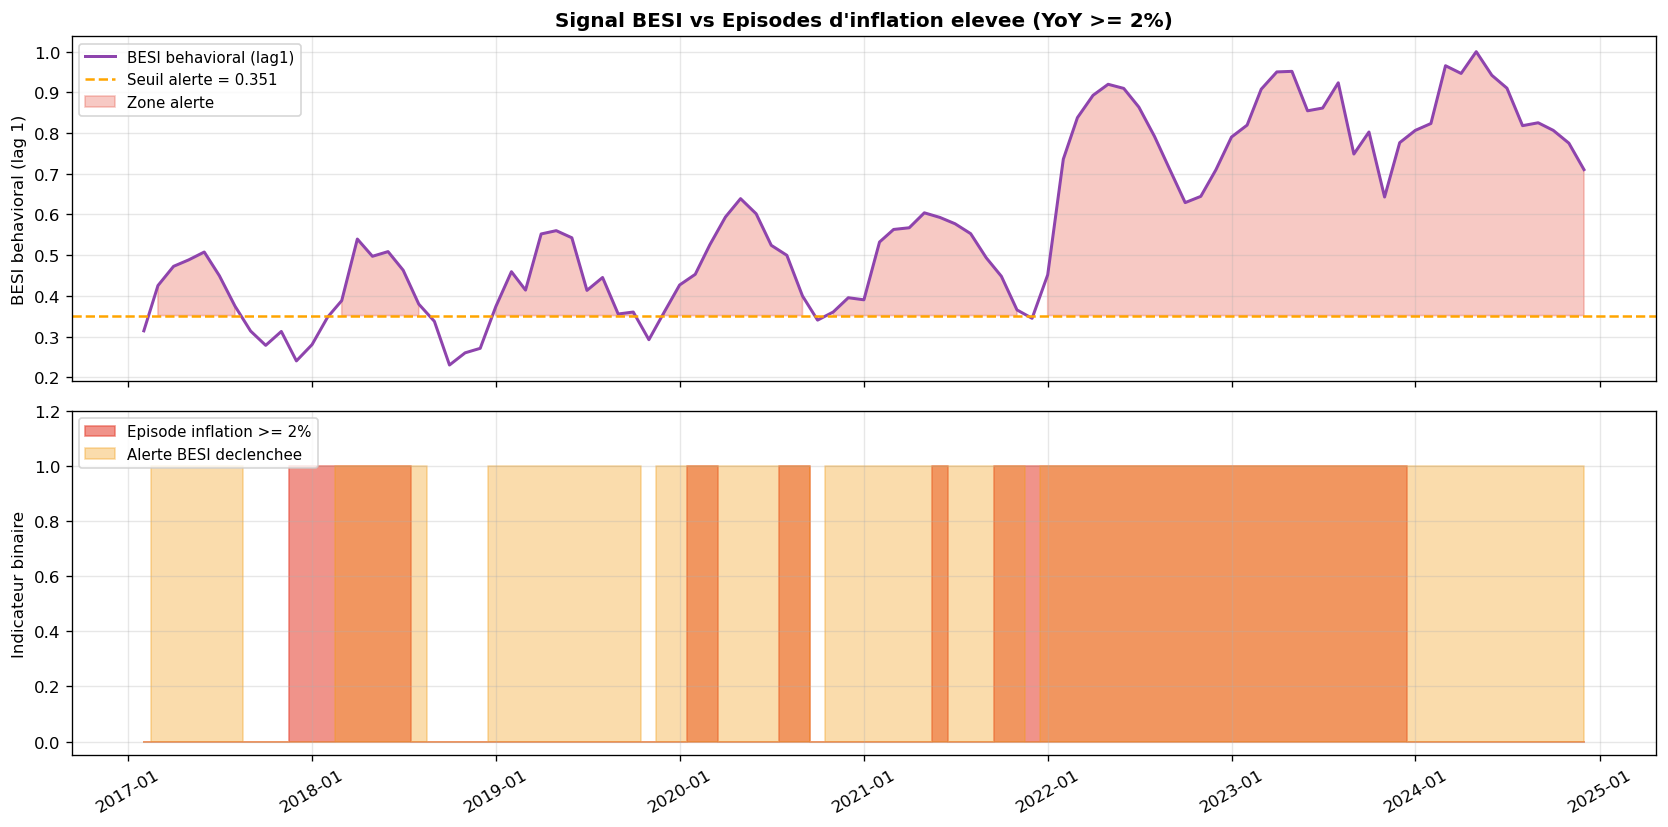

Early warning (seuil=0.351) :
  TP=36  FP=45  FN=4
  Precision=0.444  Recall=0.900  F1=0.595
  => 90% des episodes d'inflation detects


In [6]:
# ── Early warning : visualisation des alertes vs episodes d'inflation ────────
if 'behavioral_index_pure_lag1' in df.columns and 'target_high_inflation_regime_t1' in df.columns:
    wm_path = REP_DIR / 'warning_metrics_v3.csv'
    wm = pd.read_csv(wm_path)

    # Seuil global (mediane des trains)
    global_row = wm[wm['scope'] == 'global']
    threshold  = float(global_row['threshold_calibrated'].iloc[0]) if len(global_row) > 0 else 0.35

    signal    = df['behavioral_index_pure_lag1'].dropna()
    target    = df['target_high_inflation_regime_t1'].reindex(signal.index)
    alert     = signal >= threshold
    episodes  = target == 1

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    # Signal avec seuil
    ax1.plot(signal.index, signal.values, color='#8e44ad', linewidth=1.8, label='BESI behavioral (lag1)')
    ax1.axhline(threshold, color='orange', linestyle='--', linewidth=1.5, label=f'Seuil alerte = {threshold:.3f}')
    ax1.fill_between(signal.index, threshold, signal.values,
                     where=(signal >= threshold), alpha=0.3, color='#e74c3c', label='Zone alerte')
    ax1.set_ylabel('BESI behavioral (lag 1)')
    ax1.set_title('Signal BESI vs Episodes d\'inflation elevee (YoY >= 2%)', fontweight='bold')
    ax1.legend(loc='upper left', fontsize=9)

    # Episodes reels
    ax2.fill_between(episodes.index, 0, episodes.fillna(0).values,
                     step='mid', alpha=0.6, color='#e74c3c', label='Episode inflation >= 2%')
    ax2.fill_between(alert.index, 0, alert.astype(float).values,
                     step='mid', alpha=0.35, color='#f39c12', label='Alerte BESI declenchee')
    ax2.set_ylabel('Indicateur binaire')
    ax2.set_ylim(-0.05, 1.2)
    ax2.legend(loc='upper left', fontsize=9)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'early_warning_v3.png', bbox_inches='tight')
    plt.show()

    # Metriques globales
    valid = pd.DataFrame({'alert': alert, 'episode': episodes}).dropna()
    tp = ((valid['alert']) & (valid['episode'] == 1)).sum()
    fp = ((valid['alert']) & (valid['episode'] == 0)).sum()
    fn = ((~valid['alert']) & (valid['episode'] == 1)).sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    print(f'Early warning (seuil={threshold:.3f}) :')
    print(f'  TP={tp}  FP={fp}  FN={fn}')
    print(f'  Precision={precision:.3f}  Recall={recall:.3f}  F1={f1:.3f}')
    print(f'  => {recall*100:.0f}% des episodes d\'inflation detects')